#### Imports

In [1]:
import os, glob
import subprocess
import numpy as np
import pandas as pd
import pickle, shutil
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.table import Table, vstack
from datetime import datetime, timedelta

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
warnings.filterwarnings("ignore", category=UserWarning, module="gdpyc")

# Ligo-SkyMap package
import ligo.skymap.plot
from ligo.skymap.io.fits import read_sky_map

# Tilepy utilities
from tilepy.include.PointingTools import getdate
from tilepy.include.ObservationScheduler import GetSchedule
from tilepy.include.CampaignDefinition import ObservationParameters

# ODA API
from oda_api.api import DispatcherAPI

import utils, find_skymap

# Input parameters

* Very well localised GWs "GW190814", "S240615dg", "GW170818", "GW190412"
* Well localised:
* Special case: "GW190814"

In [2]:
event_name = "GW190412" # "GW190425" # "S241125n" "GW170817"

resolution_hp_to_grid = 2048
threshold_percent_gw = [0.95, 0.5]

config_tilepy = "./FollowupParameters_LST.ini" # Config file for the tiling scheduling

### Retrieving GW information and formatting data geom

Searching GWTC Catalog for GW190412
 - Found in GWTC: data/IGWN-GWTC2p1-v2-GW190412_053044_PEDataRelease_cosmo_reweight_C01:IMRPhenomXPHM.fits



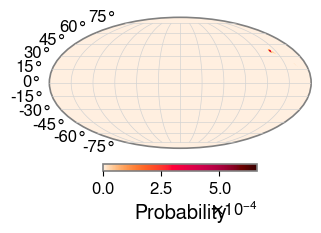

In [3]:
# Finding the file and copying it
file_skymap = find_skymap.get_skymap(event_name)

# Reading and formatting the data
# Extracting coordinates from healpy
ra_bins  = np.linspace(-180, 180, resolution_hp_to_grid)
dec_bins = np.linspace(-90, 90, resolution_hp_to_grid)
ra_grid, dec_grid = np.deg2rad(np.meshgrid(ra_bins, dec_bins))

# Reading GW data and converting to 2D geometry
data_ligo_hp, meta_ligo_hp = read_sky_map(file_skymap)
data_ligo_2d = utils.healpix2map(data_ligo_hp, ra_bins, dec_bins)

# Getting the thresholds for probability containment and hotspot
threshold_percent_gw = np.flip(np.sort(threshold_percent_gw))
threshold_maps = utils.get_hp_map_thresholds(data_ligo_hp, threshold_percent_gw)
hotspot_coord = utils.get_2d_map_hotspot(data_ligo_2d, ra_bins, dec_bins)

find_skymap.plot_gw(ra_grid, dec_grid, data_ligo_2d)

### Getting the tiling

In [4]:
obsTime = find_skymap.get_event_time(file_skymap)[0]
pointingsFile = None
datasetDir = "./data/" # Path to the input datasets (where galaxy cat should be for GW case)
outDir = "./output_tilepy/" # Path to the output folder
galcatName = None # GalCat Name

Starting the 2D pointing calculation with the following parameters

Filename:  undefined
Date: 2019-04-12 05:30:44.181992
Previous pointings: None
Dataset: ./data/
Output: ./output_tilepy//undefined
90% area = 24.70670668090373. 50% area = 4.009594250364285

Obspar:
============== Observation Parameters ======================
Observatory Name: LST
Event Name: undefined
obsTime: 2019-04-12 05:30:44.181992
---------------------- Strategy ----------------------
Algorithm = 3D, Strategy = integrated,  Mangrove = False
Do Plot = True, Do Rank = True, Count Previous= True, Second Round= False, Use Grey Time= False
--------------------- Observatory ---------------------
Observatory Location: 28.761944 deg, -17.89 deg, 2200.0 m
Wobble Offset: 0.0 deg
FOV: 2.0, Duration: 20.0, Min Duration: 10.0, Min Slewing: 0.0
Max Runs: 4, Max Nights: 1
Visibility: -18, -0.5, 65, 0, 0.0
Min Moon Source Separation: 30
Max Moon Source Separation: 145
Geomagnetic Threshold for SAA: 0
Max Zenith: 60, Zenith Weig

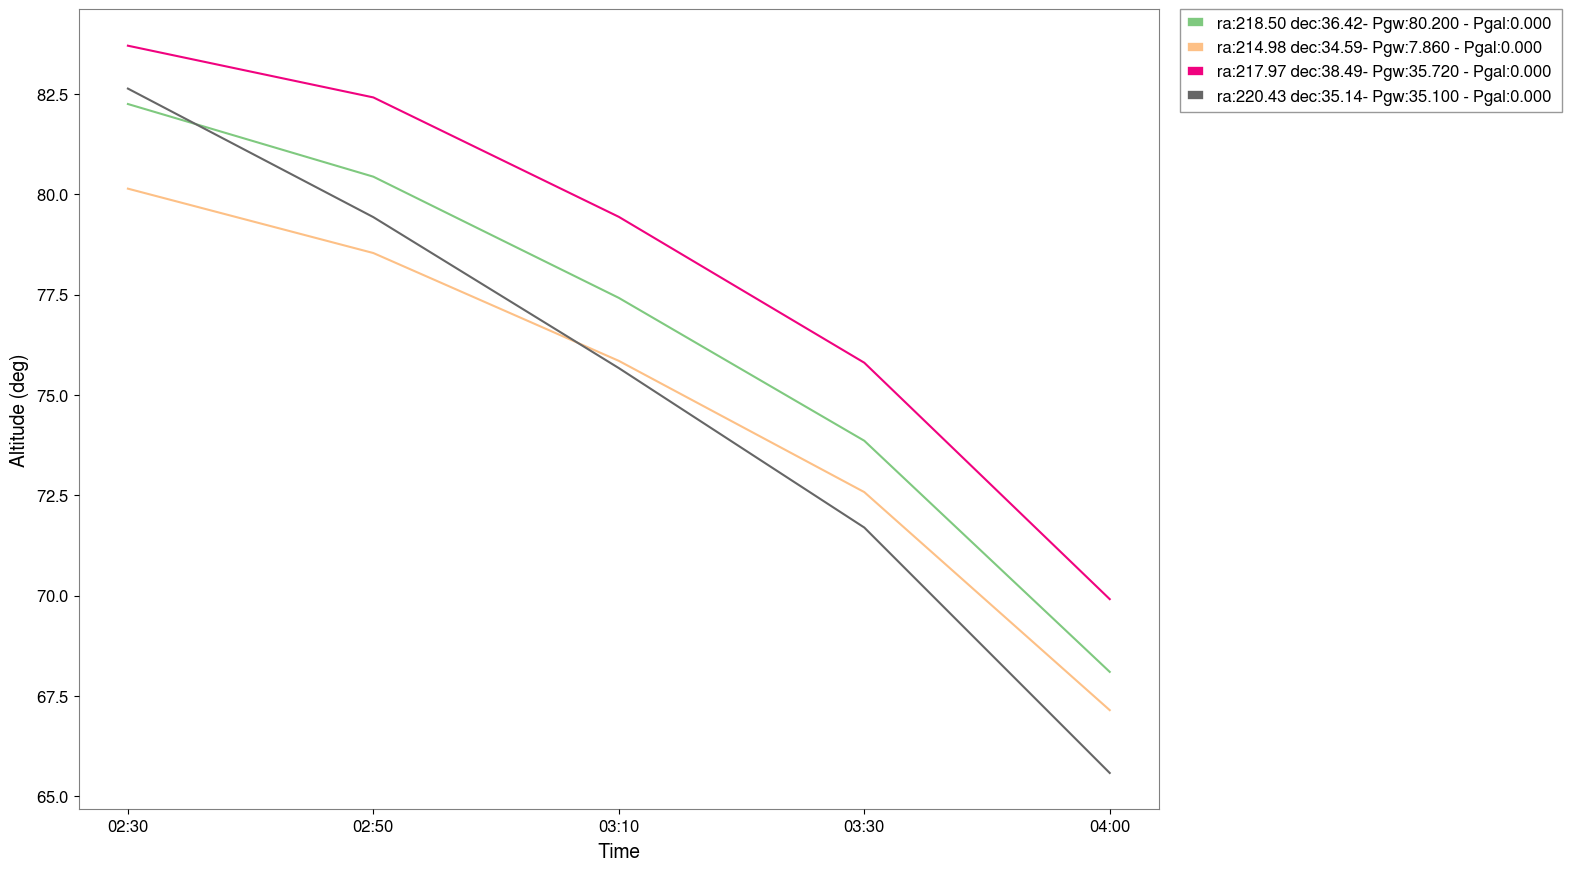

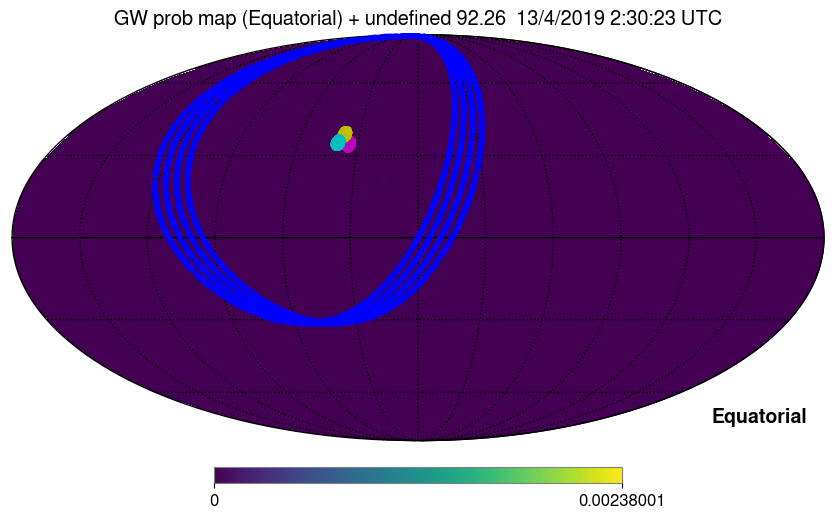

In [5]:
# Parse the parameters
obspar = ObservationParameters()
obspar.add_parsed_args(
    file_skymap, obsTime, datasetDir, galcatName, outDir, pointingsFile
)
obspar.from_configfile(config_tilepy)
display(obspar)

# We run tilepy over the SkyMap and the parameters
GetSchedule(obspar)

In [6]:
event_name_tilepy = getattr(obspar, "event_name", "undefined") 
out_dir = obspar.outDir

# Construct the path based on the log output pattern
final_pointing_path = os.path.join(
    out_dir, event_name_tilepy, "PGinFoV", "SuggestedPointings_2DProbOptimisation.txt"
); print(f"Generated pointing file at: {final_pointing_path}\n")

try:
    df = pd.read_csv(final_pointing_path, sep="\s+", engine="python")
    df.columns = df.columns.str.replace(r"\[.*\]", "", regex=True).str.strip()

    # Computing an average ZD and adding into thedf as column using astropy
    from astropy.coordinates import SkyCoord, EarthLocation, AltAz
    from astropy.time import Time
    location = EarthLocation.of_site("Roque de Los Muchachos")
    time = Time(obsTime)
    coords = SkyCoord(ra=df["RA"].values, dec=df["DEC"].values, unit="deg")
    altaz = coords.transform_to(AltAz(obstime=time, location=location))
    df["ZD"] = 90 - altaz.alt.deg
    
    display(df)
    
except FileNotFoundError:
    print(f"Error: Could not find the file at {final_pointing_path}")

Generated pointing file at: ./output_tilepy/undefined/PGinFoV/SuggestedPointings_2DProbOptimisation.txt



,Time,RA,DEC,PGW,Round,ObsName,Duration,FoV,ZD
"""2019-04-13","02:30:23""",218.4961,36.4236,0.8020,1,LST,20.0,2.0,39.330590
"""2019-04-13","02:50:23""",214.9805,34.5906,0.0634,1,LST,20.0,2.0,42.325937
"""2019-04-13","03:10:23""",217.9687,38.4913,0.0306,1,LST,20.0,2.0,39.699544
"""2019-04-13","03:30:23""",220.4297,35.1361,0.0266,1,LST,20.0,2.0,37.825611


In [11]:
%%time
output_dir = os.path.join("output_sim", event_name)
tmp_dir = os.path.join(output_dir, "tmp")
os.makedirs(tmp_dir, exist_ok=True)

for i, row in enumerate(df.itertuples()):
    t1 = datetime.fromisoformat((row[0]+"T"+row.Time).replace("\"", "").replace("\'", ""))
    t2 = t1 + timedelta(minutes=row.Duration)    
    print(f"\n[Pointing {i}] RA={row.RA}, DEC={row.DEC}")
    fname_events_i = os.path.join(output_dir, f"dl3_LST-1.Run{i:05}.fits")

    parameters_dict = {
        "src_name": f"{event_name}_{i}", 
        "DEC": row.DEC, "RA": row.RA, "Zd": row.ZD, "Emax": 100.0, "Emin": 0.1, 
        "Nwobbles": 1, "OffAxis": 0.0, "Radius_image": 3.0, "pixsize": 0.025,
        "T1": t1.isoformat(), "T2": t2.isoformat(), "T_format": "isot", "Texp": row.Duration / 60, 
        "dN_dE": "1e-16*pow(E/1000., -1.99)*exp(-E/10000)", "source_extension": 0.1, "redshift": 0.1, 
        "instrument": "ctao_lst1_simulators", "product": "LST1_events_simulator", "product_type": "Real",     
    }

    if os.path.exists(fname_events_i): 
        continue
            
    try:
        # Look for existing temporary files for this pointing index 'i'
        pointing_files = sorted(glob.glob(os.path.join(tmp_dir, f"tmp_{i}_LST1_events_simulator*.fits")))
        
        if pointing_files:
            print(f" -> Pointing {i}: Found {len(pointing_files)} cached segments in tmp. Skipping API call.")
        else:
            disp = DispatcherAPI()
            data_collection = disp.get_product(**parameters_dict, silent=True)
            
            for prod in data_collection.as_list():
                p_name = prod["prod_name"]
                if p_name.startswith("LST1_events_simulator"):
                    tmp_path = os.path.join(tmp_dir, f"tmp_{i}_{p_name}.fits")
                    getattr(data_collection, p_name).write_file(tmp_path)
                    pointing_files.append(tmp_path)
                
        if pointing_files:
            utils.create_dl3_file_lst(pointing_files, fname_events_i, i)
            print(f" -> Run {i:05} created and fixed.\n")

    except Exception as e:
        print(f"Error on pointing {i}: {e}")

# And adding index files via lstchain
str_args  = f"--input-dl3-dir={output_dir} --file-pattern=dl3*fits --overwrite"
subprocess.run(f"lstchain_create_dl3_index_files {str_args}", shell=True, text=True);


[Pointing 0] RA=218.4961, DEC=36.4236
 -> Pointing 0: Found 1 cached segments in tmp. Skipping API call.
 -> Run 00000 created and fixed.


[Pointing 1] RA=214.9805, DEC=34.5906
 -> Pointing 1: Found 1 cached segments in tmp. Skipping API call.
 -> Run 00001 created and fixed.


[Pointing 2] RA=217.9687, DEC=38.4913
 -> Pointing 2: Found 1 cached segments in tmp. Skipping API call.
 -> Run 00002 created and fixed.


[Pointing 3] RA=220.4297, DEC=35.1361
 -> Pointing 3: Found 1 cached segments in tmp. Skipping API call.
 -> Run 00003 created and fixed.



2026-03-04 16:26:02,770 ERROR [lstchain.high_level.hdu_table] (hdu_table.create_hdu_index_hdu): Run 0 does not contain HDU BACKGROUND
2026-03-04 16:26:02,770 ERROR [lstchain.high_level.hdu_table] (hdu_table.create_hdu_index_hdu): Run 0 does not contain HDU PSF
2026-03-04 16:26:02,770 ERROR [lstchain.high_level.hdu_table] (hdu_table.create_hdu_index_hdu): Run 0 does not contain HDU RAD_MAX
2026-03-04 16:26:02,772 ERROR [lstchain.high_level.hdu_table] (hdu_table.create_hdu_index_hdu): Run 1 does not contain HDU BACKGROUND
2026-03-04 16:26:02,772 ERROR [lstchain.high_level.hdu_table] (hdu_table.create_hdu_index_hdu): Run 1 does not contain HDU PSF
2026-03-04 16:26:02,772 ERROR [lstchain.high_level.hdu_table] (hdu_table.create_hdu_index_hdu): Run 1 does not contain HDU RAD_MAX
2026-03-04 16:26:02,774 ERROR [lstchain.high_level.hdu_table] (hdu_table.create_hdu_index_hdu): Run 2 does not contain HDU BACKGROUND
2026-03-04 16:26:02,774 ERROR [lstchain.high_level.hdu_table] (hdu_table.create_hd

CPU times: user 234 ms, sys: 14.6 ms, total: 248 ms
Wall time: 3.16 s
